# Scorable Judge API - SimpleQA Benchmark

Reproduces a subset of OpenAI's SimpleQA benchmark using the Scorable judge and evaluator API.

A **Scorable judge** is a versioned evaluation pipeline that groups one or more **Scorable evaluators** and runs them together against your model outputs. A Scorable evaluator is the callable unit: it takes a request, a response, and optional context, applies a scoring rubric, and returns a score with justification. The model backing each evaluator is your choice. See [our research writeup](../reports/evaluation_agents.md) for benchmarks and methodology.

**Workflow:**
1. Create a judge with a factual-correctness evaluator
2. Load SimpleQA dataset
3. Generate model answers (or bring your own)
4. Submit input/output pairs to the judge for batch evaluation
5. Poll until batch completes
6. Analyse pass rate and score distribution

**Prerequisites:**
- A Scorable API key

Ref: *SimpleQA: Measuring short-form factuality in large language models*  
Wei et al. - https://cdn.openai.com/papers/simpleqa.pdf

In [ ]:
import time

import httpx
import pandas as pd

In [ ]:
SCORABLE_API_KEY = "your-api-key"
BASE_URL = "https://api.scorable.ai"

# Number of SimpleQA examples to evaluate
BATCH_N = 100

# LLM to use for answer generation (litellm model string)
GENERATION_MODEL = "gpt-5.4"

client = httpx.Client(
    base_url=BASE_URL,
    headers={"Authorization": f"Api-Key {SCORABLE_API_KEY}"},
    timeout=600.0,
)

## 1. Create judge

Creates an objective, a Scorable evaluator, and a judge that wraps it. The evaluator prompt embeds the reference answer inside `{{request}}` so the model can compare against it.

Scorable evaluators support rubric inference from examples, multiple evaluation modes (pointwise, pairwise, policy compliance), and return calibrated confidence alongside every score. For this benchmark we use a simple factual-correctness rubric; the same infrastructure supports arbitrarily complex criteria.

Skip this section and set `JUDGE_ID` manually if you already have a judge configured.

In [ ]:
EVALUATOR_PROMPT = """\
You are evaluating whether a model's answer to a factual question is correct.

{{request}}

Model answer: {{response}}

Score 1.0 if the answer is factually correct (minor variations in phrasing, \
capitalisation, or formatting are acceptable as long as the core fact matches). \
Score 0.0 if the answer is incorrect or if the model admits it does not know.\
"""

# 1. Create an objective (the intent that drives the evaluator)
obj = client.post(
    "/v1/objectives/",
    json={"intent": "Evaluate factual correctness of model answers against a reference answer"},
)
obj.raise_for_status()
objective_id = obj.json()["id"]
print(f"Objective: {objective_id}")

# 2. Create the evaluator
ev = client.post(
    "/v1/evaluators/",
    json={
        "name": "SimpleQA Factual Correctness",
        "prompt": EVALUATOR_PROMPT,
        "is_evaluator": True,
        "objective_id": objective_id,
    },
)
ev.raise_for_status()
evaluator_id = ev.json()["id"]
print(f"Evaluator: {evaluator_id}")

# 3. Create the judge with the evaluator attached
jg = client.post(
    "/v1/judges/",
    json={
        "name": "SimpleQA Judge",
        "intent": "Evaluate factual correctness on SimpleQA benchmark",
        "evaluator_references": [{"id": evaluator_id}],
    },
)
jg.raise_for_status()
JUDGE_ID = jg.json()["id"]
print(f"Judge: {JUDGE_ID}  ← save this to skip setup on future runs")

## 2. Load SimpleQA dataset

In [ ]:
simple_qa = pd.read_csv(
    "https://openaipublic.blob.core.windows.net/simple-evals/simple_qa_test_set.csv"
)

# Stable integer IDs for tracking rows across steps
simple_qa_indexed = pd.DataFrame(
    [{"question_id": idx, **row} for idx, row in simple_qa.iterrows()]
)

sample_df = simple_qa_indexed[:BATCH_N].copy()
print(f"Loaded {len(simple_qa_indexed)} examples, using {len(sample_df)}")
sample_df[["question_id", "problem", "answer"]].head()

## 3. Generate model answers

Use litellm to generate a concise answer for each question.  
Skip this section and set `sample_df["model_response"]` manually if you already have responses.

In [ ]:
from litellm import completion

SYSTEM_PROMPT = (
    "You are a factual question-answering assistant. "
    "Answer each question with a concise response, ideally 1-3 words. "
    "If you do not know the answer, say 'I don't know'."
)


def generate_answer(question: str) -> str:
    response = completion(
        model=GENERATION_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
        ],
        temperature=0.0,
    )
    return response.choices[0].message.content.strip()


print(f"Generating answers with {GENERATION_MODEL} for {len(sample_df)} examples...")
sample_df["model_response"] = sample_df["problem"].apply(generate_answer)
print("Done.")
sample_df[["problem", "answer", "model_response"]].head(10)

## 4. Submit to Scorable judge for batch evaluation

Sends batches of up to 100 items to `POST /v1/judges/{judge_id}/batch-execute/`.  
Each `request` field embeds both the question and the reference answer so the evaluator
can compare them. The `response` field carries the model's answer.

In [ ]:
MAX_BATCH_SIZE = 100  # enforced by the API

rows = sample_df.to_dict("records")
chunks = [rows[i : i + MAX_BATCH_SIZE] for i in range(0, len(rows), MAX_BATCH_SIZE)]

batch_ids = []
for i, chunk in enumerate(chunks):
    payload = {
        "inputs": [
            {
                "request": f"Question: {row['problem']}\nReference answer: {row['answer']}",
                "response": row["model_response"],
            }
            for row in chunk
        ],
        "tags": ["simpleqa-benchmark", GENERATION_MODEL],
    }
    resp = client.post(f"/v1/judges/{JUDGE_ID}/batch-execute/", json=payload)
    if resp.status_code != 202:
        print(f"Chunk {i}: error {resp.status_code} - {resp.text}")
    else:
        data = resp.json()
        batch_ids.append(data["batch_execution_id"])
        print(f"Chunk {i}: submitted batch {data['batch_execution_id']}")

print(f"\n{len(batch_ids)} batch(es) submitted")

## 5. Poll until batches complete

In [ ]:
def poll_batch(batch_id: str, poll_interval: int = 10, max_wait: int = 3600) -> dict:
    start = time.time()
    while time.time() - start < max_wait:
        resp = client.get(f"/v1/judges/batch-executions/{batch_id}/")
        data = resp.json()
        elapsed = int(time.time() - start)
        print(
            f"[{elapsed:4d}s] {data['status']:12s} "
            f"{data['completed_count']}/{data['total_count']} completed, "
            f"{data['failed_count']} failed"
        )
        if data["status"] in ("completed", "partial", "failed"):
            return data
        time.sleep(poll_interval)
    raise TimeoutError(f"Batch {batch_id} did not complete within {max_wait}s")


all_batches = []
for bid in batch_ids:
    print(f"\nPolling {bid}")
    result = poll_batch(bid)
    all_batches.append(result)
    print(f"Final status: {result['status']}")

## 6. Analyse results

In [ ]:
records = []
for batch in all_batches:
    for item in batch.get("items", []):
        for eval_result in item.get("evaluator_results") or []:
            records.append(
                {
                    "batch_index": item["index"],
                    "item_status": item["status"],
                    "evaluator_name": eval_result["evaluator_name"],
                    "score": eval_result["score"],
                    "justification": eval_result["justification"],
                }
            )

results_df = pd.DataFrame(records)

results_df = results_df.merge(
    sample_df[["question_id", "problem", "answer", "model_response"]].reset_index(drop=True),
    left_on="batch_index",
    right_index=True,
    how="left",
)

print(f"Total evaluated items: {len(results_df)}")
results_df.head()

In [ ]:
# Score >= 0.5 → pass  (evaluators return 0.0-1.0)
results_df["pass"] = results_df["score"] >= 0.5

summary = (
    results_df.groupby("evaluator_name")
    .agg(
        n=("score", "count"),
        pass_rate=("pass", "mean"),
        mean_score=("score", "mean"),
        std_score=("score", "std"),
    )
    .reset_index()
)
summary["pass_rate"] = summary["pass_rate"].map("{:.1%}".format)

print(f"Model: {GENERATION_MODEL}")
print(f"Examples evaluated: {results_df['question_id'].nunique()}")
print()
summary

In [ ]:
# Score distribution
results_df.groupby("evaluator_name")["score"].describe()

In [ ]:
# Inspect failures
pd.set_option("display.max_colwidth", None)

results_df[~results_df["pass"]].sort_values("score")[
    ["problem", "answer", "model_response", "score", "justification"]
].head(15)

> **Illustrative outputs** - the plots below are pre-populated from internal benchmark runs on the SimpleQA dataset using GPT-5 and RootJudge-120B-v2 models evaluated with Scorable evaluators. They show confidence calibration curves (evaluator confidence vs. actual accuracy), a threshold sweep for triage operating points, and a confusion matrix of evaluator predictions vs. ground truth. See [the research writeup](../reports/evaluation_agents.md) for full methodology and confidence intervals. Your own results will appear here after running the cells above.

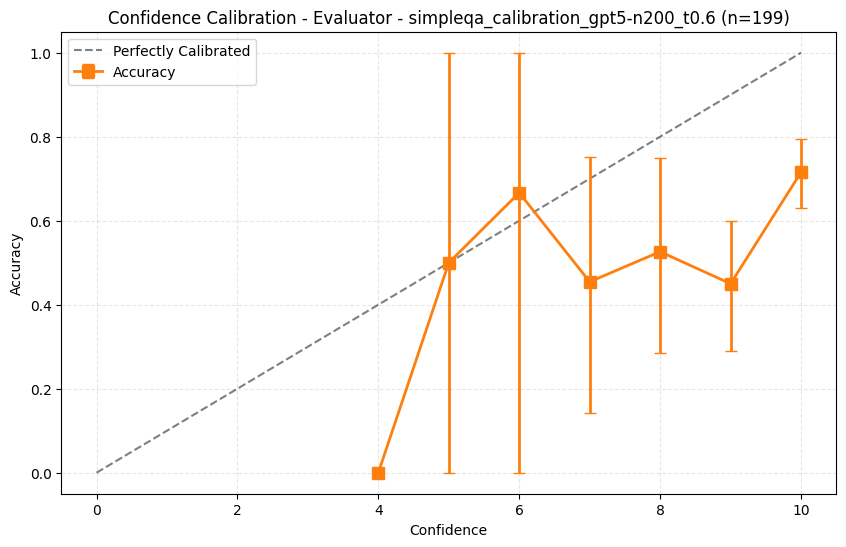

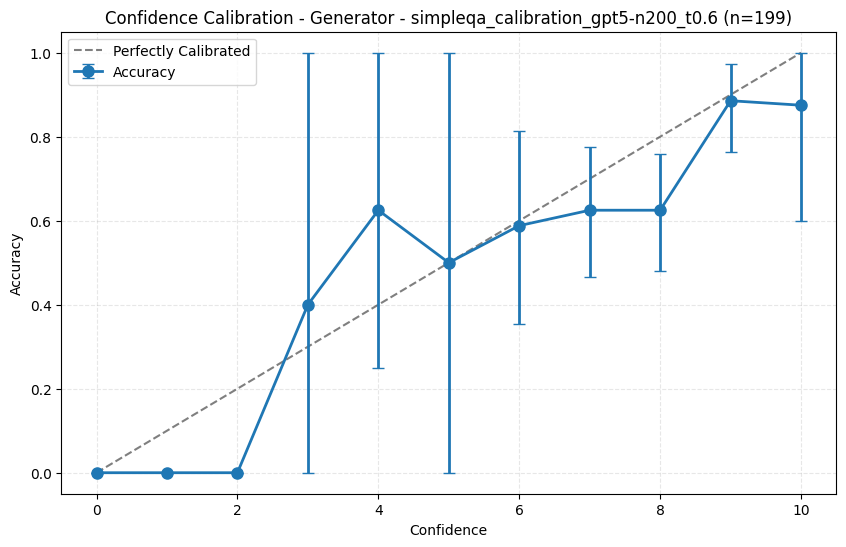

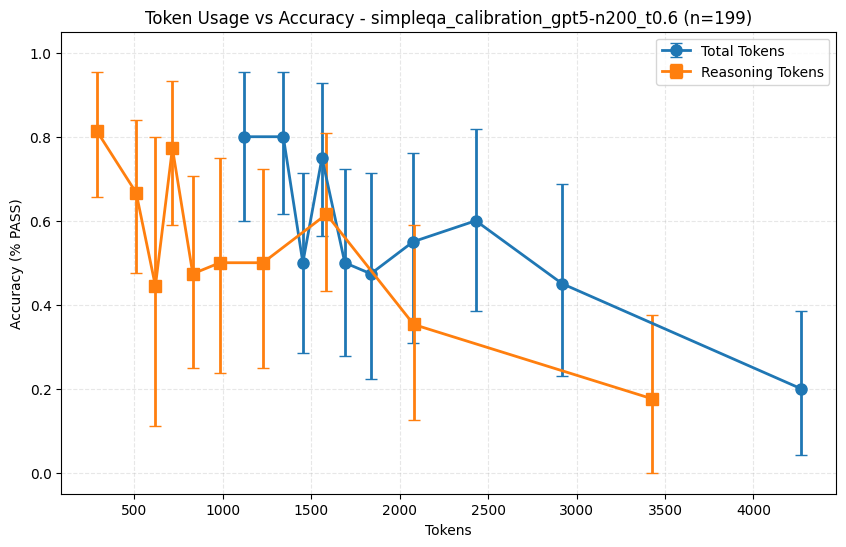

In [ ]:
# Confidence calibration curves - GPT-5 & RootJudge-120B-v2

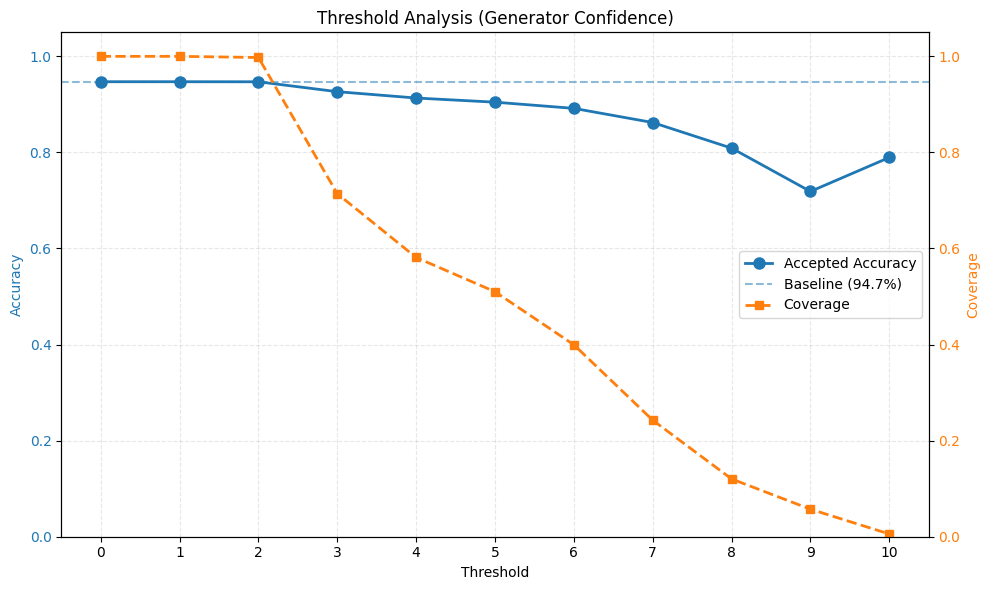

In [ ]:
# Threshold sweep

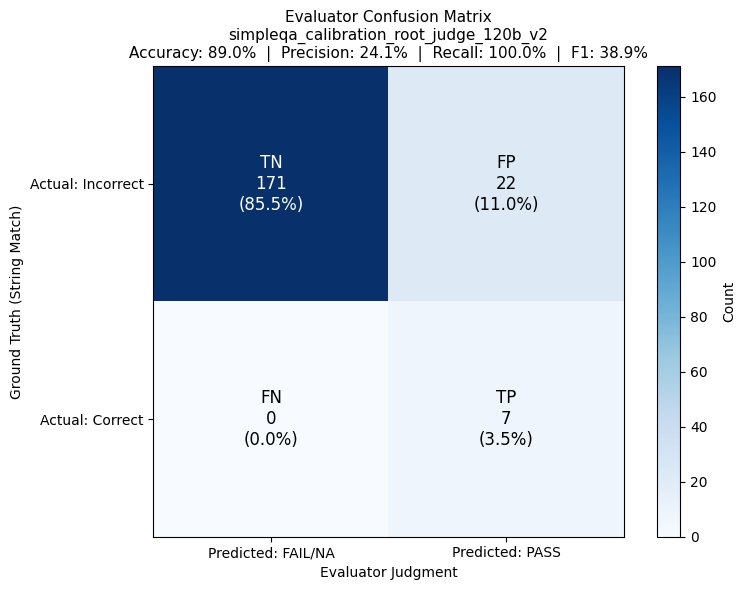

In [ ]:
# Confusion matrix